# Intro to Spoken Language Processing with Python

## Import an audio file

In [1]:
# Get a sample sound file from this website https://freesound.org/people/barrigan/sounds/60689/

In [2]:
# Open the file
import wave # Wave doesn't need to be installed, it is in python by default

good_morning = wave.open("60689__barrigan__good-morning.wav", "r")

Error: unknown format: 65534

In [ ]:
# The audio files is in format 65534 (wave_format_extensive) needs to be converted to pcm format
# 
# -acodec pcm_s16le (16bit PCM)
# -ar 44100(sample rate 44.1kHz or 441000 cycles per second)
# -ac 1 (mono audio, change to 2 for stereo if needed)
# 
#! ffmpeg -i 60689__barrigan__good-morning.wav -acodec pcm_s16le -ar 44100 -ac 2 output.wav


## Transform a sound file into numbers

In [ ]:
# Import audio files as wave object

import wave

soundwave = wave.open("output.wav", "r")
soundwave

In [ ]:
# Convert wave object to bytes
# -1 means we want to read all the pieces of information within the wave object
soundbytes = soundwave.readframes(-1)
# View the wav file in byte form
soundbytes[:10]

b'\x00\x00\xff\xff\xfe\xff\xfd\xff\xfb\xff'

In [ ]:
# Convert from bytes to integers
import numpy as np

soundsignal = np.frombuffer(soundbytes, dtype="int16")
soundsignal[:10]
# How long is the whole array? 
#
# Frequency is a measurement of information per second
# The sound last 10seconds
# The frequency is 441000
# Then there is 10s*44.1kHz = 4 410 000


array([ 0, -1, -2, -3, -5, -6, -7, -7, -8, -8], dtype=int16)

In [ ]:
# Finding the frame rate
# Frequency (Hz) = length of the wave object array/duration of audio file (seconds)
framerate = soundwave.getframerate()
framerate

44100

In [ ]:
# Duration of audio file (seconds) = length of wave of object array/frequency (Hz)
duration = len(soundsignal)/framerate
duration

9.800612244897959

In [ ]:
# Finding sound wave timestampts
# Return evenly space values between start and stop
np.linspace(start=1, stop=10, num=10)

time = np.linspace(start=0, stop=duration, num=len(soundsignal))
time[:10] # Each of these values is the time in secodns where each sound wave byte occured

array([0.00000000e+00, 2.26757894e-05, 4.53515789e-05, 6.80273683e-05,
       9.07031577e-05, 1.13378947e-04, 1.36054737e-04, 1.58730526e-04,
       1.81406315e-04, 2.04082105e-04])

## Visualizing sound waves

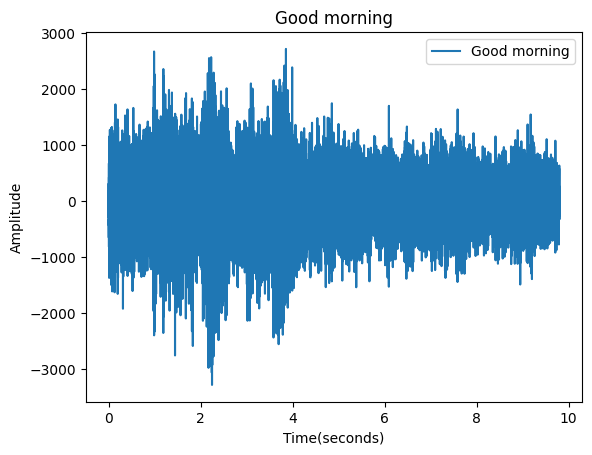

In [ ]:
import matplotlib.pyplot as plt
plt.title("Good morning")
plt.xlabel("Time(seconds)")
plt.ylabel("Amplitude")
plt.plot(time, soundsignal, label="Good morning")
plt.legend()
plt.show()